In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

Matplotlib is building the font cache; this may take a moment.


In [6]:
import subprocess
subprocess.run(["pip", "install", "xlrd"], check=True)

CompletedProcess(args=['pip', 'install', 'xlrd'], returncode=0)

In [2]:
import pandas as pd
df = pd.read_excel("All Recorded Traffic.xls", engine="xlrd")
print("Loaded successfully!")
print("Shape:", df.shape)
df.head()





Loaded successfully!
Shape: (65535, 1)


,DAY\tDATE\tFAC\tLANE\tTIME\tTOTAL\tCLASS 1\tCLASS 2\tCLASS 3\tCLASS 4\tCLASS 5\tCLASS 6\tCLASS 7\tCLASS 8\tCLASS 9\tCLASS 11\tCASH\tEZPASS\tVIOLATION\tLANEMODE\tMonth\tFAC_B\tAutos\tSmall_T\tLarge_T\tBuses\tYr\tFAC_G\tFAC_G2\tDay_Name
0,4\t2022-09-15 00:00:00.000\t2\t6\t100\t1\t1\tN...
1,4\t2022-09-15 00:00:00.000\t2\t6\t300\t1\tNULL...
2,4\t2022-09-15 00:00:00.000\t2\t6\t400\t73\t67\...
3,4\t2022-09-15 00:00:00.000\t2\t6\t500\t713\t67...
4,4\t2022-09-15 00:00:00.000\t2\t6\t600\t1003\t9...


In [6]:
import pandas as pd

df = pd.read_excel("All Recorded Traffic.xls", engine="xlrd")

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 3 rows:")
df.head(3)

Shape: (65535, 1)

Column names:
['DAY\tDATE\tFAC\tLANE\tTIME\tTOTAL\tCLASS 1\tCLASS 2\tCLASS 3\tCLASS 4\tCLASS 5\tCLASS 6\tCLASS 7\tCLASS 8\tCLASS 9\tCLASS 11\tCASH\tEZPASS\tVIOLATION\tLANEMODE\tMonth\tFAC_B\tAutos\tSmall_T\tLarge_T\tBuses\tYr\tFAC_G\tFAC_G2\tDay_Name']

First 3 rows:


,DAY\tDATE\tFAC\tLANE\tTIME\tTOTAL\tCLASS 1\tCLASS 2\tCLASS 3\tCLASS 4\tCLASS 5\tCLASS 6\tCLASS 7\tCLASS 8\tCLASS 9\tCLASS 11\tCASH\tEZPASS\tVIOLATION\tLANEMODE\tMonth\tFAC_B\tAutos\tSmall_T\tLarge_T\tBuses\tYr\tFAC_G\tFAC_G2\tDay_Name
0,4\t2022-09-15 00:00:00.000\t2\t6\t100\t1\t1\tN...
1,4\t2022-09-15 00:00:00.000\t2\t6\t300\t1\tNULL...
2,4\t2022-09-15 00:00:00.000\t2\t6\t400\t73\t67\...


In [7]:
import pandas as pd

df = pd.read_excel("All Recorded Traffic.xls", engine="xlrd", header=None)

# The single column contains tab-separated data — split it into proper columns
df = df[0].str.split("\t", expand=True)

# First row is the header
df.columns = df.iloc[0]      # set column names from row 0
df = df.iloc[1:].reset_index(drop=True)  # drop the header row from data

# Replace NULL strings with actual NaN
df = df.replace("NULL", None)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

Shape: (65535, 30)
Columns: ['DAY', 'DATE', 'FAC', 'LANE', 'TIME', 'TOTAL', 'CLASS 1', 'CLASS 2', 'CLASS 3', 'CLASS 4', 'CLASS 5', 'CLASS 6', 'CLASS 7', 'CLASS 8', 'CLASS 9', 'CLASS 11', 'CASH', 'EZPASS', 'VIOLATION', 'LANEMODE', 'Month', 'FAC_B', 'Autos', 'Small_T', 'Large_T', 'Buses', 'Yr', 'FAC_G', 'FAC_G2', 'Day_Name']


,DAY,DATE,FAC,LANE,TIME,TOTAL,CLASS 1,CLASS 2,CLASS 3,CLASS 4,...,Month,FAC_B,Autos,Small_T,Large_T,Buses,Yr,FAC_G,FAC_G2,Day_Name
0,4,2022-09-15 00:00:00.000,2,6,100,1,1,None,None,None,...,9,Lincoln,1,0,0,0,2022,Tunnels,Lincoln,Thursday
1,4,2022-09-15 00:00:00.000,2,6,300,1,None,None,None,None,...,9,Lincoln,1,0,0,0,2022,Tunnels,Lincoln,Thursday
2,4,2022-09-15 00:00:00.000,2,6,400,73,67,2,1,1,...,9,Lincoln,67,3,1,2,2022,Tunnels,Lincoln,Thursday


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import os
# ── CLEAN & PREPARE ───────────────────────────────────────────────────────────
df["TOTAL"] = pd.to_numeric(df["TOTAL"], errors="coerce")
df["TIME"]  = pd.to_numeric(df["TIME"],  errors="coerce")
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Yr"]    = pd.to_numeric(df["Yr"],    errors="coerce")
df["DATE"]  = pd.to_datetime(df["DATE"], errors="coerce")

# TIME is 0–2300 format (e.g. 800 = 8 AM) → convert to hour 0–23
df["Hour"] = (df["TIME"] / 100).astype("Int64")

MONTH_NAMES = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
              7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
df["Month_Name"] = df["Month"].map(MONTH_NAMES)

DAY_ORDER  = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
FAC_COLORS = ["#2a6ebb","#e07b39","#3ba07a","#c0392b","#8e44ad","#16a085"]

os.makedirs("traffic_outputs", exist_ok=True)

print(f"Records  : {len(df):,}")
print(f"Dates    : {df['DATE'].min().date()} → {df['DATE'].max().date()}")
print(f"Facilities: {sorted(df['FAC_G2'].dropna().unique())}")

Records  : 65,535
Dates    : 2013-01-02 → 2025-04-07
Facilities: ['Bayonne', 'GWB', 'Goethals', 'Holland', 'Lincoln', 'Outerbridge']



── Hourly Traffic Volume ──
Hour_Label  Total_Volume
     00:00        406394
     01:00        274744
     02:00        218218
     03:00        223851
     04:00        371334
     05:00        948059
     06:00       1289792
     07:00       1241426
     08:00       1212873
     09:00       1242225
     10:00       1228530
     11:00       1191902
     12:00       1177133
     13:00       1188829
     14:00       1219793
     15:00       1245510
     16:00       1284603
     17:00       1328858
     18:00       1314147
     19:00       1132316
     20:00       1002602
     21:00        911952
     22:00        775523
     23:00        566052


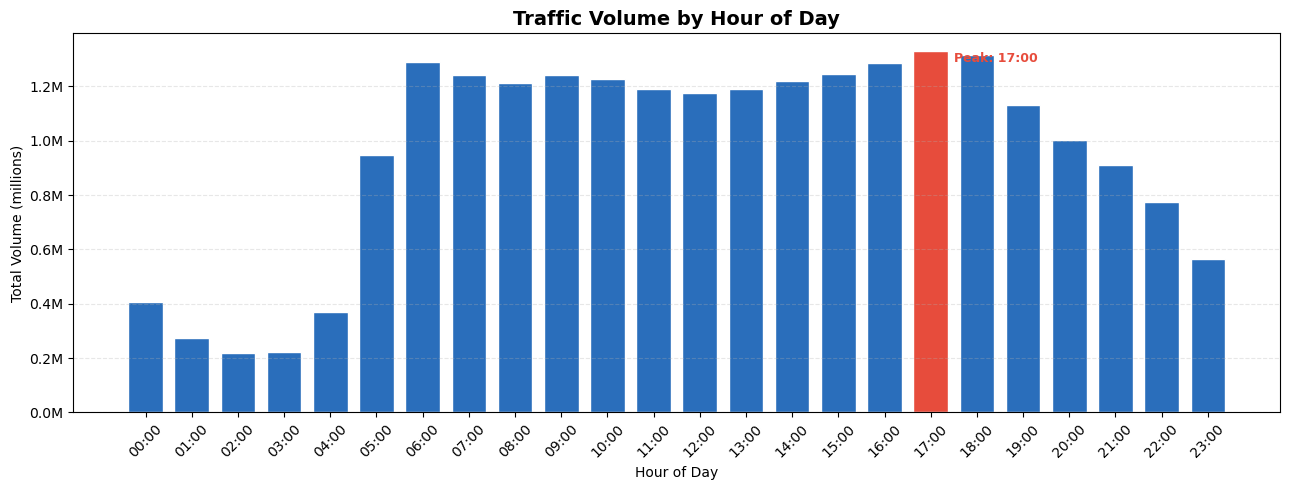

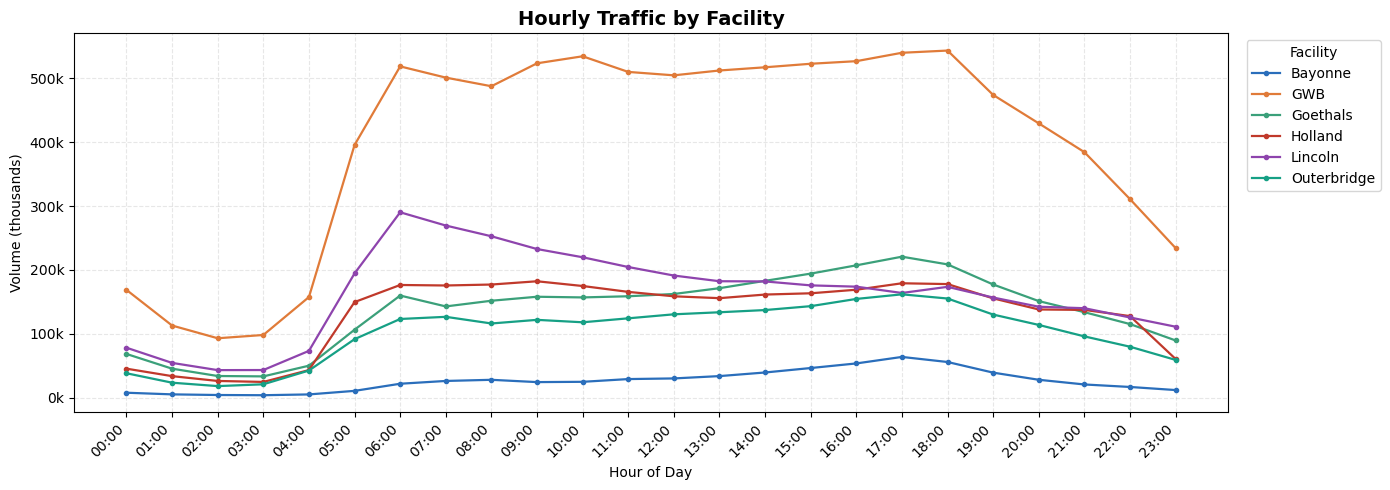

In [9]:
by_hour = df.groupby("Hour")["TOTAL"].sum().reset_index()
by_hour.columns = ["Hour", "Total_Volume"]
by_hour["Hour_Label"] = by_hour["Hour"].apply(lambda h: f"{int(h):02d}:00")

print("\n── Hourly Traffic Volume ──")
print(by_hour[["Hour_Label","Total_Volume"]].to_string(index=False))

# Chart A1 — Overall by hour
peak_idx   = by_hour["Total_Volume"].idxmax()
bar_colors = ["#e74c3c" if i == peak_idx else "#2a6ebb" for i in by_hour.index]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(by_hour["Hour_Label"], by_hour["Total_Volume"] / 1e6,
       color=bar_colors, edgecolor="white", width=0.75)
ax.set_title("Traffic Volume by Hour of Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Total Volume (millions)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.annotate(f"Peak: {by_hour.loc[peak_idx,'Hour_Label']}",
            xy=(peak_idx, by_hour['Total_Volume'].max() / 1e6),
            xytext=(peak_idx + 0.5, by_hour['Total_Volume'].max() / 1e6 * 0.97),
            color="#e74c3c", fontweight="bold", fontsize=9)
plt.tight_layout()
plt.savefig("traffic_outputs/A1_traffic_by_hour.png", dpi=150)
plt.show()

# Chart A2 — By hour per facility
by_hour_fac = df.groupby(["Hour","FAC_G2"])["TOTAL"].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
for col, color in zip(by_hour_fac.columns, FAC_COLORS):
    ax.plot(by_hour_fac.index, by_hour_fac[col] / 1e3,
            marker="o", ms=3, linewidth=1.6, label=col, color=color)
ax.set_title("Hourly Traffic by Facility", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Volume (thousands)")
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))
ax.legend(title="Facility", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("traffic_outputs/A2_traffic_by_hour_facility.png", dpi=150, bbox_inches="tight")
plt.show()


── Traffic Volume by Day ──
      Day  Total_Volume
   Monday       5814056
  Tuesday       3018352
Wednesday       2437305
 Thursday       3146763
   Friday       2242383
 Saturday       2964799
   Sunday       3373008


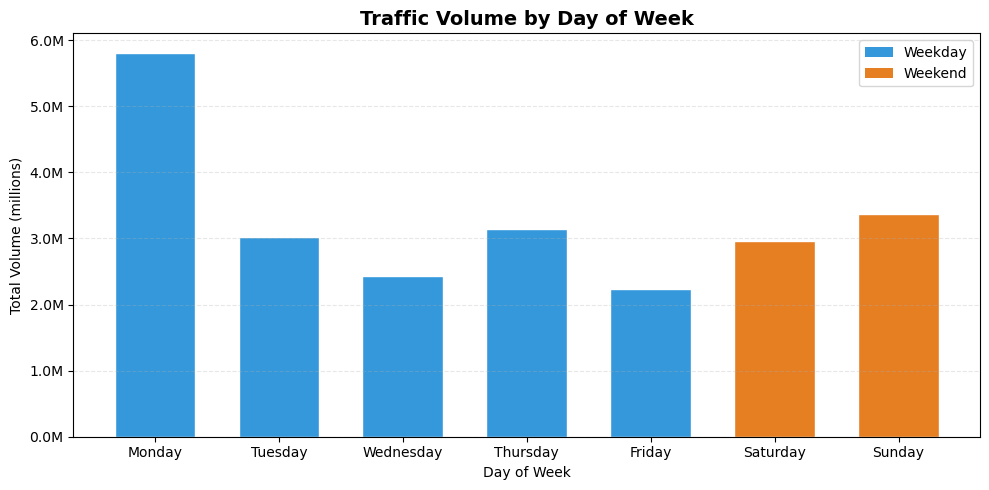

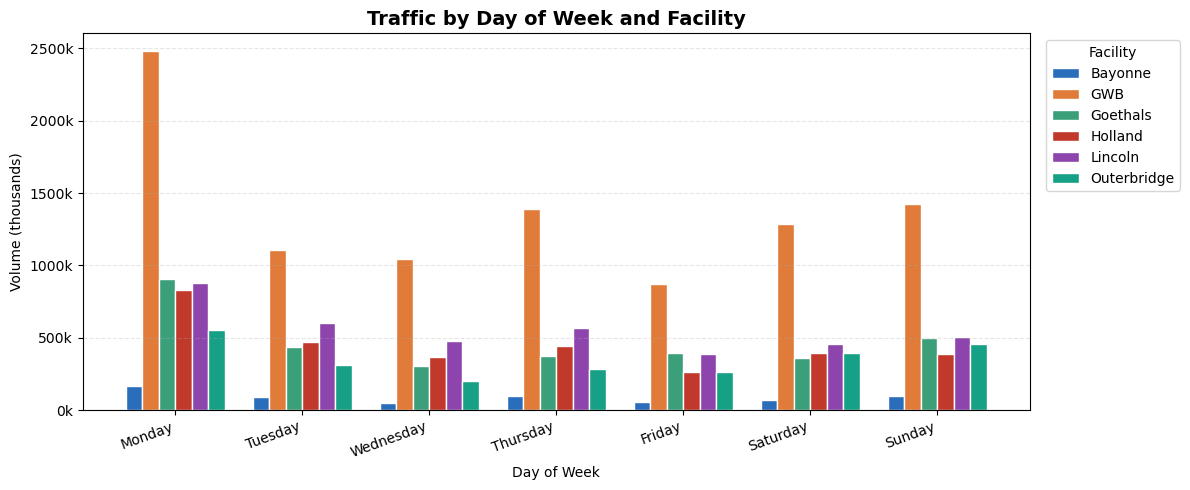

In [10]:
by_day = (df.groupby("Day_Name")["TOTAL"]
          .sum()
            .reindex([d for d in DAY_ORDER if d in df["Day_Name"].unique()])
           .reset_index())
by_day.columns = ["Day", "Total_Volume"]

print("\n── Traffic Volume by Day ──")
print(by_day.to_string(index=False))

# Chart B1 — Overall by day
WEEKDAY_COLORS = {d: "#3498db" for d in DAY_ORDER[:5]}
WEEKDAY_COLORS.update({"Saturday": "#e67e22", "Sunday": "#e67e22"})
bar_colors_d = [WEEKDAY_COLORS.get(d, "#95a5a6") for d in by_day["Day"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(by_day["Day"], by_day["Total_Volume"] / 1e6,
       color=bar_colors_d, edgecolor="white", width=0.65)
ax.set_title("Traffic Volume by Day of Week", fontsize=14, fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Total Volume (millions)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.legend(handles=[Patch(facecolor="#3498db", label="Weekday"),
                   Patch(facecolor="#e67e22", label="Weekend")])
plt.tight_layout()
plt.savefig("traffic_outputs/B1_traffic_by_day.png", dpi=150)
plt.show()

# Chart B2 — By day per facility
by_day_fac = (df.groupby(["Day_Name","FAC_G2"])["TOTAL"]
                .sum()
                .unstack(fill_value=0)
                .reindex([d for d in DAY_ORDER if d in df["Day_Name"].unique()]))

fig, ax = plt.subplots(figsize=(12, 5))
x     = range(len(by_day_fac))
width = 0.13
for i, (fac, color) in enumerate(zip(by_day_fac.columns, FAC_COLORS)):
    offset = (i - len(by_day_fac.columns) / 2 + 0.5) * width
    ax.bar([xi + offset for xi in x], by_day_fac[fac] / 1e3,
           width=width, label=fac, color=color, edgecolor="white")
ax.set_title("Traffic by Day of Week and Facility", fontsize=14, fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Volume (thousands)")
ax.set_xticks(list(x))
ax.set_xticklabels(by_day_fac.index, rotation=20, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))
ax.legend(title="Facility", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("traffic_outputs/B2_traffic_by_day_facility.png", dpi=150, bbox_inches="tight")
plt.show()




── Traffic Volume by Month ──
Month  Total_Volume
  Jan        544223
  Feb       4632406
  Mar       4780187
  Apr        256445
  Jun        121202
  Jul        216480
  Aug       2277059
  Sep       9230103
  Oct         85617
  Nov        794921
  Dec         58023


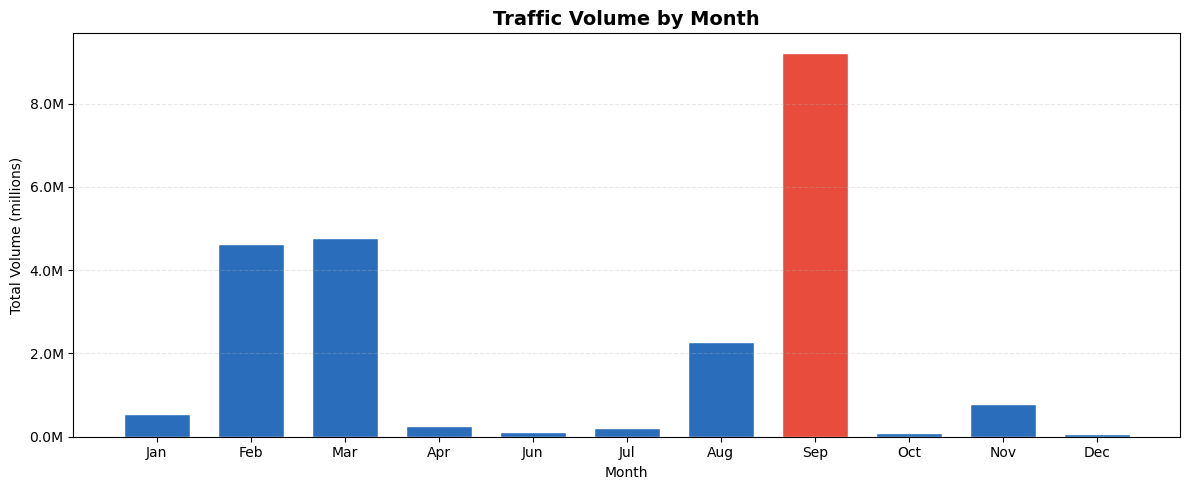

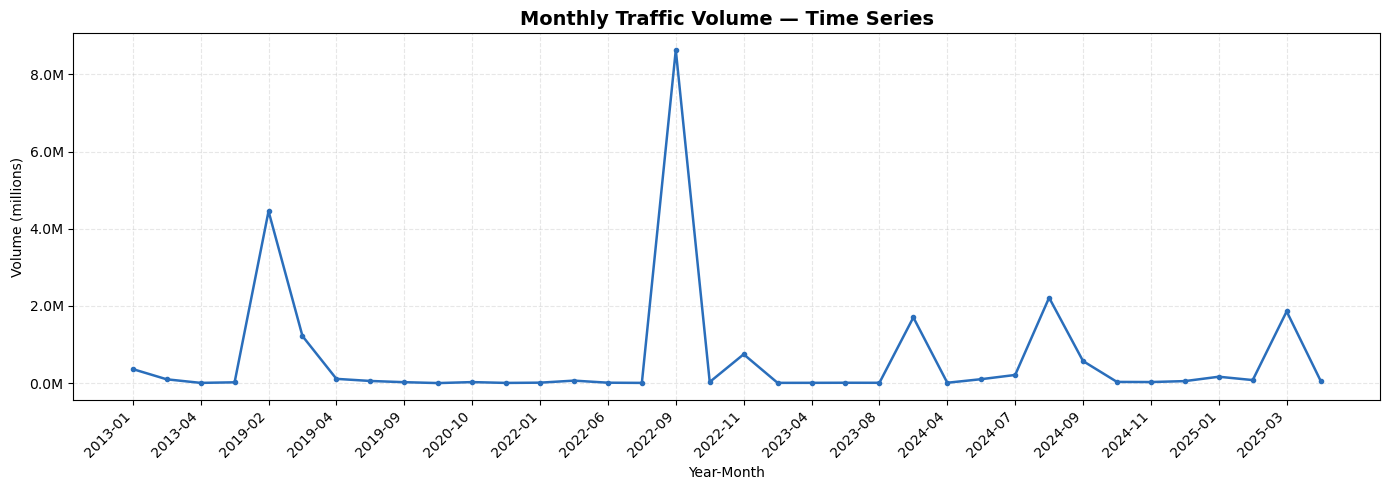

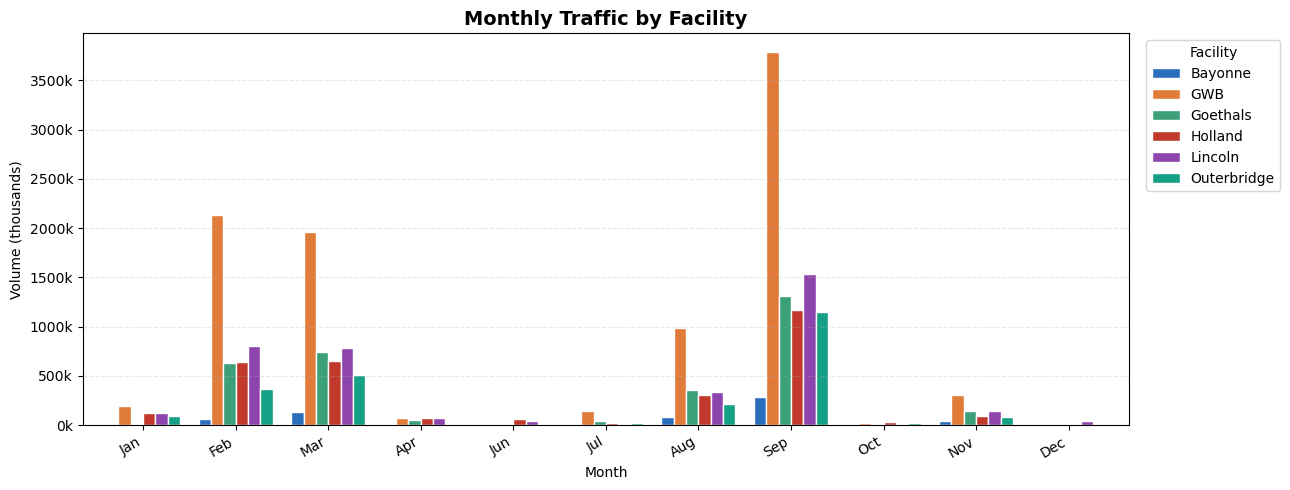

In [11]:
by_month = (df.groupby(["Month","Month_Name"])["TOTAL"]
             .sum().reset_index().sort_values("Month"))
by_month.columns = ["Month_Num","Month","Total_Volume"]

print("\n── Traffic Volume by Month ──")
print(by_month[["Month","Total_Volume"]].to_string(index=False))

# Chart C1 — Overall by month
peak_m       = by_month["Total_Volume"].idxmax()
bar_colors_m = ["#e74c3c" if i == peak_m else "#2a6ebb" for i in by_month.index]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(by_month["Month"], by_month["Total_Volume"] / 1e6,
       color=bar_colors_m, edgecolor="white", width=0.7)
ax.set_title("Traffic Volume by Month", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Volume (millions)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("traffic_outputs/C1_traffic_by_month.png", dpi=150)
plt.show()

# Chart C2 — Monthly time series
by_ym = (df.groupby(["Yr","Month","Month_Name"])["TOTAL"]
           .sum().reset_index().sort_values(["Yr","Month"]))
by_ym.columns = ["Yr","Month_Num","Month_Name","Total_Volume"]
by_ym["Period"] = by_ym["Yr"].astype(str) + "-" + by_ym["Month_Num"].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(by_ym)), by_ym["Total_Volume"] / 1e6,
        color="#2a6ebb", linewidth=1.8, marker="o", ms=3)
ticks = range(0, len(by_ym), max(1, len(by_ym) // 14))
ax.set_xticks(list(ticks))
ax.set_xticklabels([by_ym["Period"].iloc[i] for i in ticks], rotation=45, ha="right")
ax.set_title("Monthly Traffic Volume — Time Series", fontsize=14, fontweight="bold")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Volume (millions)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("traffic_outputs/C2_traffic_monthly_timeseries.png", dpi=150)
plt.show()

# Chart C3 — By month per facility
pivot_mf = (df.groupby(["Month","Month_Name","FAC_G2"])["TOTAL"]
           .sum().reset_index().sort_values("Month")
              .pivot_table(index=["Month","Month_Name"], columns="FAC_G2",
                           values="TOTAL", aggfunc="sum", fill_value=0))
pivot_mf.index = [mn for _, mn in pivot_mf.index]

fig, ax = plt.subplots(figsize=(13, 5))
pivot_mf.div(1e3).plot(kind="bar", ax=ax,
                        color=FAC_COLORS[:len(pivot_mf.columns)],
                        edgecolor="white", width=0.8)
ax.set_title("Monthly Traffic by Facility", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Volume (thousands)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Facility", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("traffic_outputs/C3_traffic_by_month_facility.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
with pd.ExcelWriter("traffic_outputs/traffic_breakdown_summary.xlsx") as writer:
   by_hour.to_excel(writer,  sheet_name="By_Hour",             index=False)
    by_day.to_excel(writer,   sheet_name="By_Day",              index=False)
    by_month.to_excel(writer, sheet_name="By_Month",            index=False)
    by_ym.to_excel(writer,    sheet_name="Monthly_TimeSeries",  index=False)
    by_hour_fac.reset_index().to_excel(writer, sheet_name="Hour_by_Facility",  index=False)
    by_day_fac.reset_index().to_excel(writer,  sheet_name="Day_by_Facility",   index=False)
    pivot_mf.reset_index().to_excel(writer,    sheet_name="Month_by_Facility", index=False)

print("\n✅ Done! Saved to: traffic_outputs/")
print("   Charts : A1, A2 (Hour) | B1, B2 (Day) | C1, C2, C3 (Month)")
226print("   Excel  : traffic_breakdown_summary.xlsx — 7 sheets")
227